<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Function_transformer_Day_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [5]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipython-input-694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [33]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
xtrain

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


/tmp/ipython-input-2239609222.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xtrain['Age'])


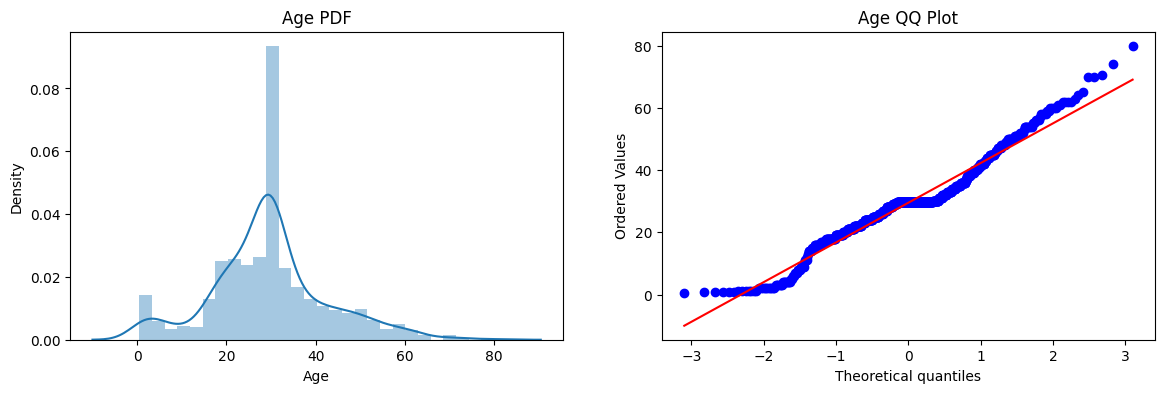

In [11]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(xtrain['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(xtrain['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

/tmp/ipython-input-606695521.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(xtrain['Fare'])


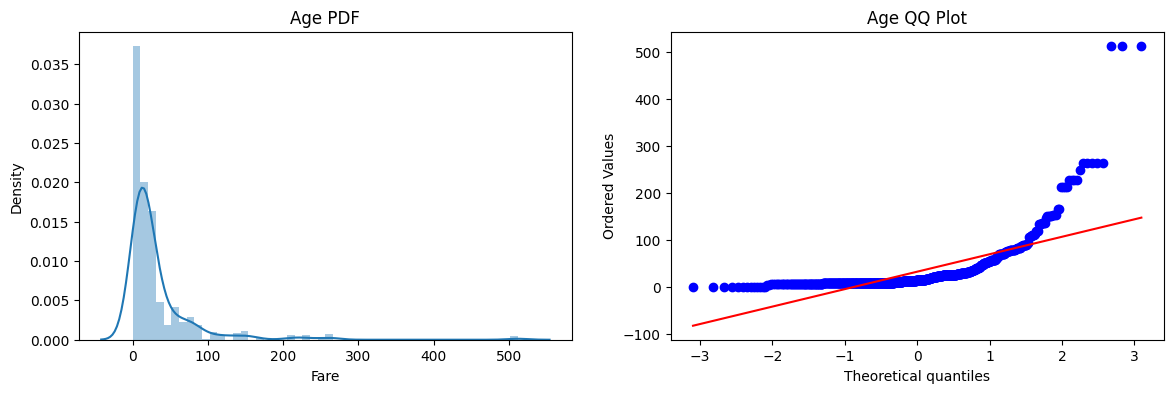

In [12]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(xtrain['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(xtrain['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [13]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [14]:
clf.fit(xtrain,ytrain)
clf2.fit(xtrain,ytrain)

y_pred = clf.predict(xtest)
y_pred1 = clf2.predict(xtest)

print("Accuracy LR",accuracy_score(ytest,y_pred))
print("Accuracy DT",accuracy_score(ytest,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6424581005586593


# function transform

In [17]:
trf=FunctionTransformer(func=np.log1p)

In [18]:
xtrain_transformed=trf.fit_transform(xtrain)
xtest_tranformed=trf.transform(xtest)

In [22]:
clf=LogisticRegression()
clf1=DecisionTreeClassifier()

clf.fit(xtrain_transformed,ytrain)
clf1.fit(xtrain_transformed,ytrain)

ypred=clf.predict(xtest_tranformed)
y_pred1=clf1.predict(xtest_tranformed)

print("Accuracy LR",accuracy_score(ytest,ypred))
print("Accuracy DT",accuracy_score(ytest,y_pred1))


Accuracy LR 0.6815642458100558
Accuracy DT 0.6703910614525139


In [23]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6622097378277154


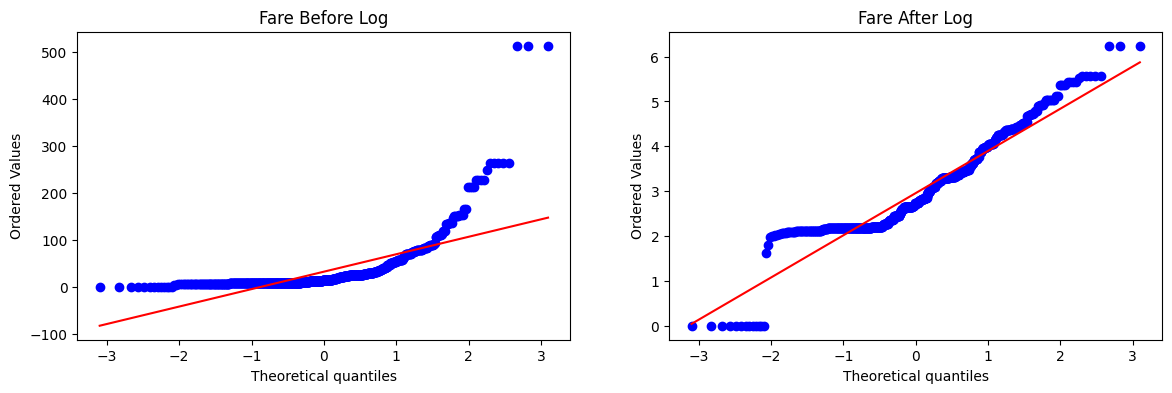

In [24]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(xtrain['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(xtrain_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

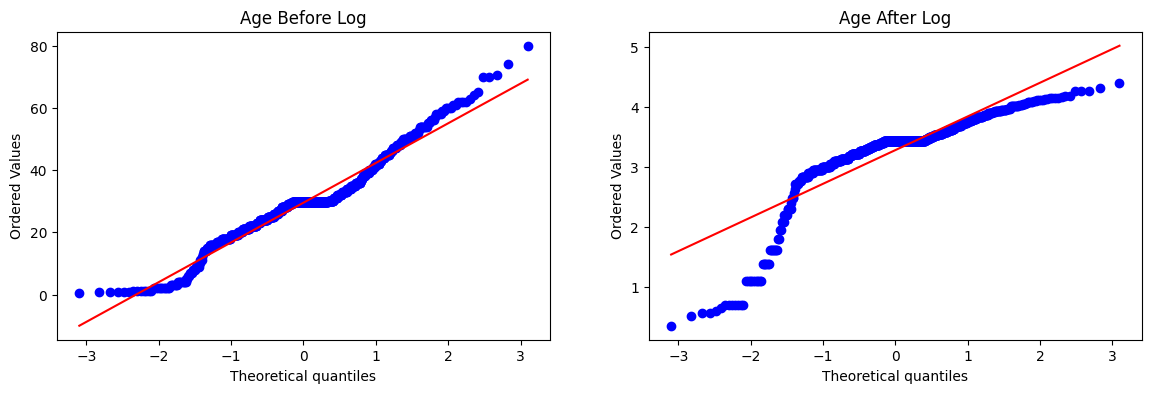

In [25]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(xtrain['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(xtrain_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [26]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(xtrain)
X_test_transformed2 = trf2.transform(xtest)

In [27]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,ytrain)
clf2.fit(X_train_transformed2,ytrain)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(ytest,y_pred))
print("Accuracy DT",accuracy_score(ytest,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972


In [28]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6633208489388265


In [29]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6712609238451936


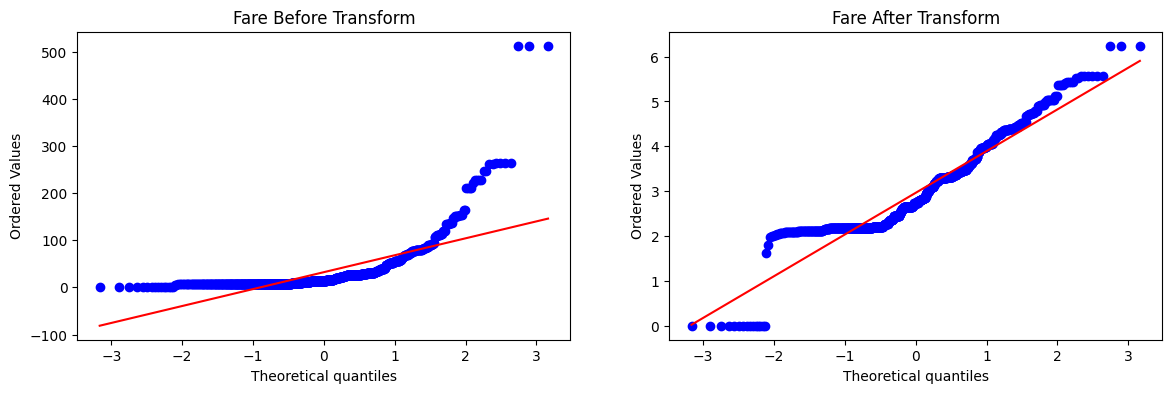

In [32]:
apply_transform(np.log1p)